In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the billings data
df = pd.read_csv('../../data/raw/billings.csv')

# Print basic info
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 Rows:")
print(df.head())
print(f"\nData Types:")
print(df.dtypes)

Dataset Shape: (122082, 59)

First 5 Rows:
   Co_Ref Renewal_Month  Connection_Net  Connection_Qty Discount_Amount  \
0  VT6174    01-11-2024             NaN             NaN             NaN   
1  VD3828    01-08-2025             NaN             NaN             NaN   
2  DV8120    01-03-2025             NaN             NaN             NaN   
3  EZ9894    01-06-2025             NaN             NaN             NaN   
4  FA8957    01-03-2025             NaN             NaN             NaN   

   Sustainability_Score  Total_Renewal_Score_New  Starting_Connection_Net  \
0                   8.0                     42.5                      NaN   
1                   8.0                     41.5                      NaN   
2                   8.0                     33.0                      NaN   
3                   9.5                     44.5                      NaN   
4                   9.5                     42.5                      NaN   

   Starting_Connection_Qty  Last_Years_Pric

C:\Users\vaddi\AppData\Local\Temp\ipykernel_19784\2079013023.py:7: DtypeWarning: Columns (0: Proforma_Auto_Renewal, 1: Proforma_World_Pay_Token, 2: Current_Anchor_List, 3: Last_Renewal, 4: Last_Band) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/raw/billings.csv')


In [24]:
# Column Inventory: all columns with their dtypes and null counts
column_info = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df) * 100).round(2)
})

# Flag numeric columns stored as object
numeric_as_object = []
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            pd.to_numeric(df[col].dropna())
            numeric_as_object.append(col)
        except:
            pass

print("COLUMN INVENTORY:")
print(column_info.to_string(index=False))

if numeric_as_object:
    print(f" NUMERIC COLUMNS STORED AS OBJECT: {numeric_as_object}")

COLUMN INVENTORY:
                    Column Data Type  Null Count  Null %
                    Co_Ref       str           0    0.00
             Renewal_Month       str           0    0.00
            Connection_Net   float64      114045   93.42
            Connection_Qty   float64      114045   93.42
           Discount_Amount       str      108531   88.90
      Sustainability_Score   float64           0    0.00
   Total_Renewal_Score_New   float64           0    0.00
   Starting_Connection_Net   float64      113537   93.00
   Starting_Connection_Qty   float64      113537   93.00
          Last_Years_Price   float64        9090    7.45
      Last_Years_Date_Paid   float64      122082  100.00
        Auto_Renewal_Score     int64           0    0.00
             Status_Scores     int64           0    0.00
           Anchoring_Score   float64           0    0.00
             Tenure_Scores   float64           0    0.00
     Proforma_Auto_Renewal    object       18052   14.79
  Proforma_Wo

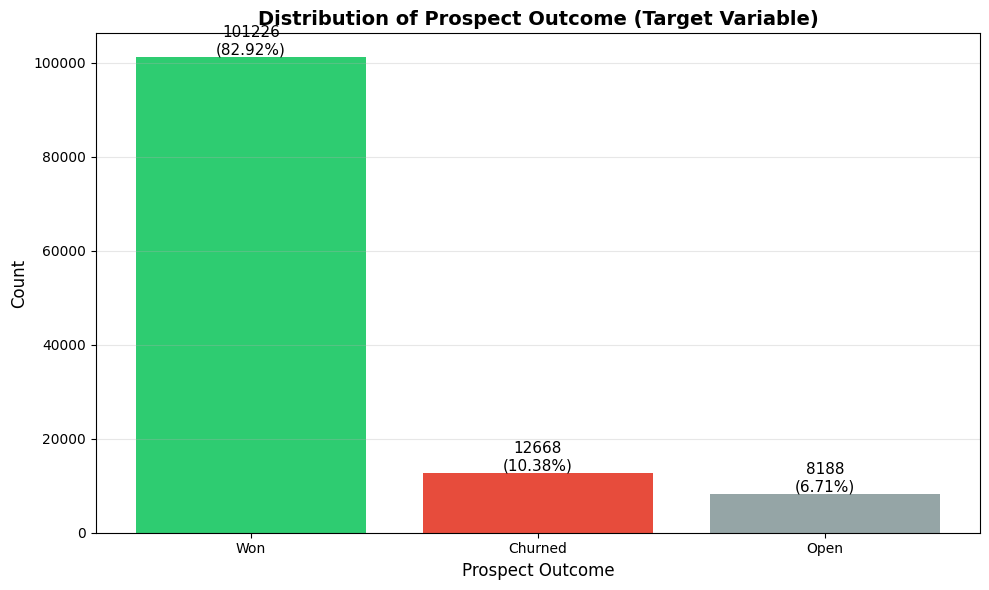


=== OUTCOME ANALYSIS ===

Outcome Distribution:
Prospect_Outcome
Won        101226
Churned     12668
Open         8188
Name: count, dtype: int64

Outcome Percentage:
Prospect_Outcome
Won        82.92
Churned    10.38
Open        6.71
Name: count, dtype: float64

Churn Rate (among Won/Churned): 11.12%
Open/Incomplete Labels: 8188 (6.71%)


In [15]:
# Cell 3: The Outcome Column (your target)
# Count and percentage of each Prospect_Outcome value
outcome_counts = df['Prospect_Outcome'].value_counts()
outcome_pct = (outcome_counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(outcome_counts.index, outcome_counts.values, color=['#2ecc71', '#e74c3c', '#95a5a6'])

# Add count and percentage labels on bars
for i, (count, pct) in enumerate(zip(outcome_counts.values, outcome_pct.values)):
    ax.text(i, count, f'{count}\n({pct}%)', ha='center', va='bottom', fontsize=11)

ax.set_xlabel('Prospect Outcome', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Prospect Outcome (Target Variable)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Answer key questions
print("\n=== OUTCOME ANALYSIS ===")
print(f"\nOutcome Distribution:")
print(outcome_counts)
print(f"\nOutcome Percentage:")
print(outcome_pct)

# Calculate churn rate among decided outcomes
decided = df[df['Prospect_Outcome'] != 'Open']
if len(decided) > 0:
    churn_rate = (decided['Prospect_Outcome'] == 'Churned').sum() / len(decided) * 100
    print(f"\nChurn Rate (among Won/Churned): {churn_rate:.2f}%")
    
print(f"Open/Incomplete Labels: {(df['Prospect_Outcome'] == 'Open').sum()} ({outcome_pct['Open']}%)")

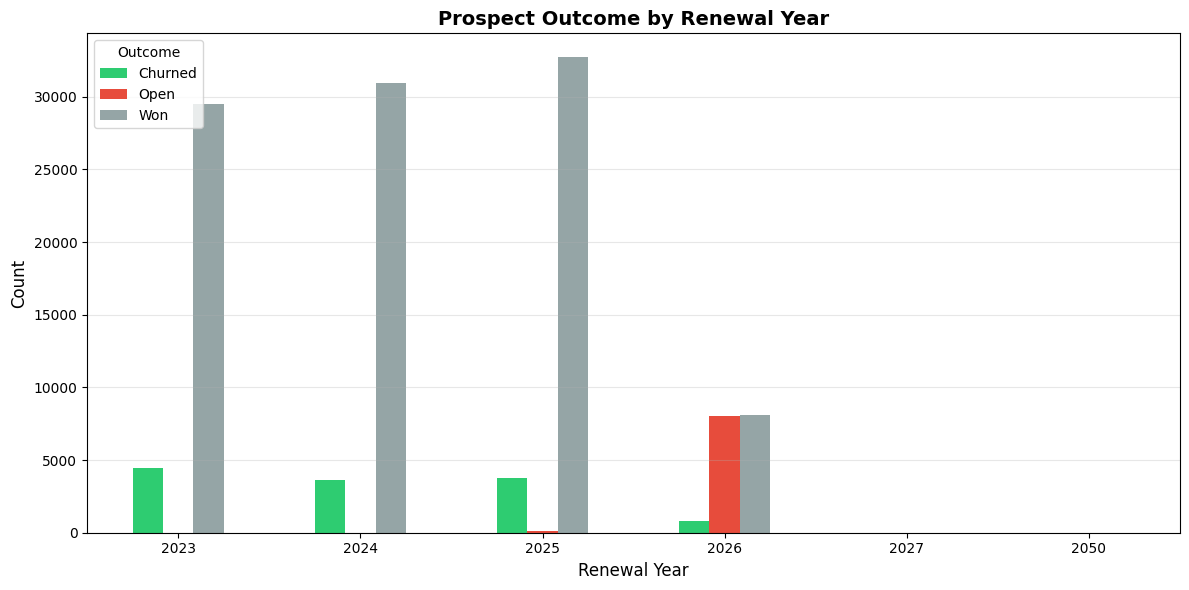


=== OUTCOME BY YEAR ANALYSIS ===
Prospect_Outcome  Churned  Open    Won
Renewal_Year                          
2023                 4455     0  29470
2024                 3655     0  30946
2025                 3737   138  32726
2026                  820  8049   8081
2027                    1     0      1
2050                    0     1      2

Churn Rate by Year (among decided outcomes):
2023: 13.13% churn | 0.00% open labels
2024: 10.56% churn | 0.00% open labels
2025: 10.25% churn | 0.38% open labels
2026: 9.21% churn | 47.49% open labels
2027: 50.00% churn | 0.00% open labels
2050: 0.00% churn | 33.33% open labels


In [16]:
# Cell 4: Outcome by Year
# Grouped bar chart: Renewal_Year vs Prospect_Outcome
outcome_by_year = pd.crosstab(df['Renewal_Year'], df['Prospect_Outcome'])

fig, ax = plt.subplots(figsize=(12, 6))
outcome_by_year.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c', '#95a5a6'])
ax.set_xlabel('Renewal Year', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Prospect Outcome by Renewal Year', fontsize=14, fontweight='bold')
ax.legend(title='Outcome', loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n=== OUTCOME BY YEAR ANALYSIS ===")
print(outcome_by_year)

# Calculate churn rate per year
print("\nChurn Rate by Year (among decided outcomes):")
for year in sorted(df['Renewal_Year'].dropna().unique()):
    year_data = df[df['Renewal_Year'] == year]
    decided = year_data[year_data['Prospect_Outcome'] != 'Open']
    if len(decided) > 0:
        churn_pct = (decided['Prospect_Outcome'] == 'Churned').sum() / len(decided) * 100
        open_pct = (year_data['Prospect_Outcome'] == 'Open').sum() / len(year_data) * 100
        print(f"{year}: {churn_pct:.2f}% churn | {open_pct:.2f}% open labels")
    else:
        print(f"{year}: All labels are Open")

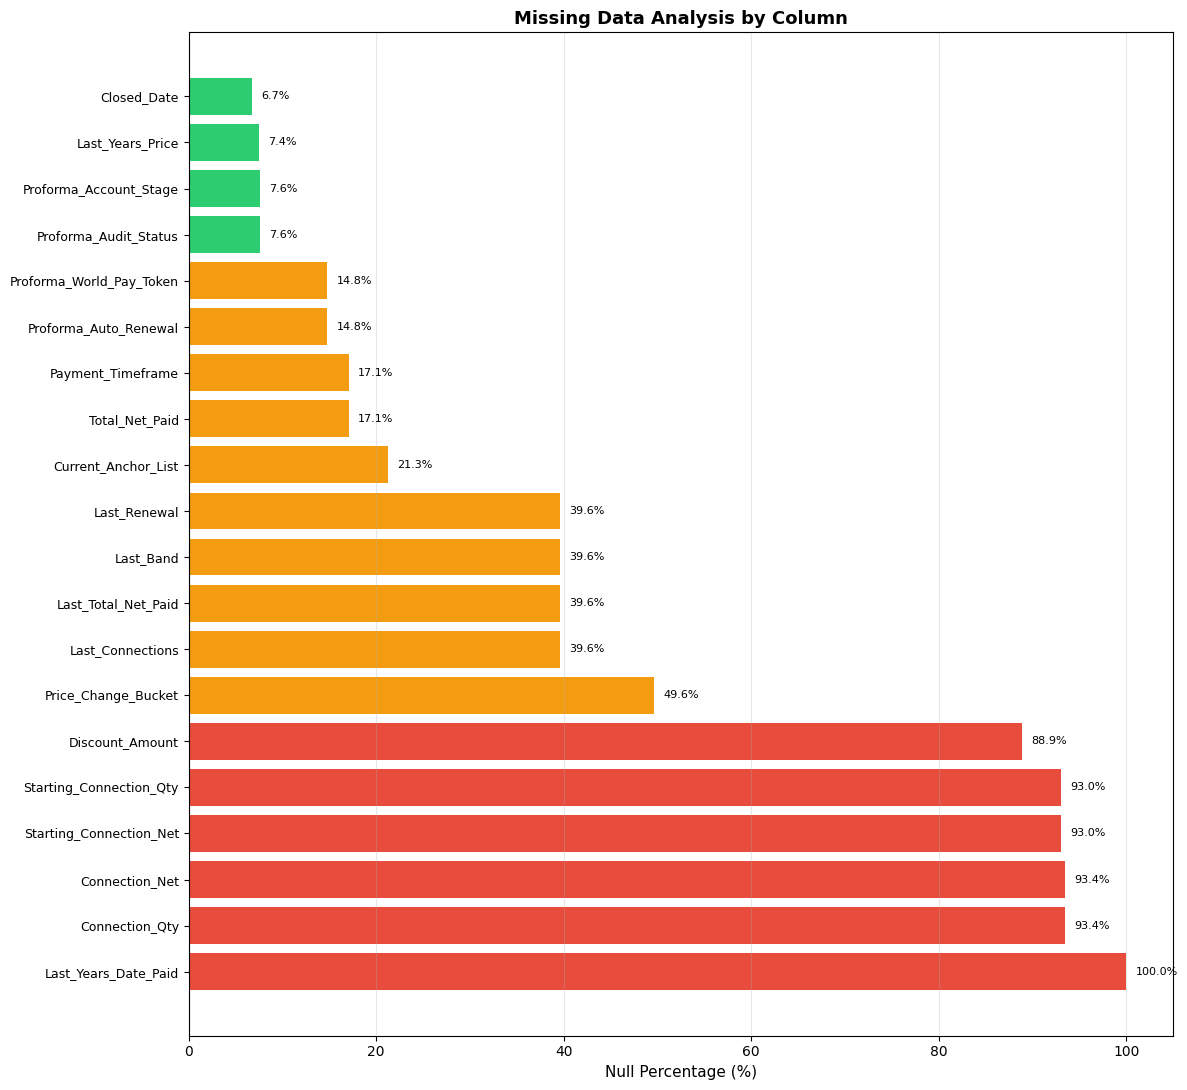


=== NULL ANALYSIS ===
                    Column  Null Count  Null %
      Last_Years_Date_Paid      122082  100.00
            Connection_Qty      114045   93.42
            Connection_Net      114045   93.42
   Starting_Connection_Net      113537   93.00
   Starting_Connection_Qty      113537   93.00
           Discount_Amount      108531   88.90
       Price_Change_Bucket       60579   49.62
          Last_Connections       48380   39.63
       Last_Total_Net_Paid       48356   39.61
                 Last_Band       48311   39.57
              Last_Renewal       48291   39.56
       Current_Anchor_List       25957   21.26
            Total_Net_Paid       20856   17.08
         Payment_Timeframe       20856   17.08
     Proforma_Auto_Renewal       18052   14.79
  Proforma_World_Pay_Token       18052   14.79
     Proforma_Audit_Status        9229    7.56
    Proforma_Account_Stage        9229    7.56
          Last_Years_Price        9090    7.45
               Closed_Date        818

In [30]:
# Cell 5: Null Analysis
# Horizontal bar chart sorted by null percentage
# if null percentage is above 1 then show in the graph otherwise ignore
null_counts = df.isnull().sum().sort_values(ascending=False)
null_pct = (null_counts / len(df) * 100)
null_pct_plt = null_pct[null_pct > 1.0].sort_values(ascending=False)

# Define colors based on threshold
colors = []
for pct in null_pct_plt:
    if pct > 50:
        colors.append('#e74c3c')  # red
    elif pct >= 10:
        colors.append('#f39c12')  # orange
    else:
        colors.append('#2ecc71')  # green

fig, ax = plt.subplots(figsize=(12, len(null_pct_plt) // 2 + 1))
ax.barh(range(len(null_pct_plt)), null_pct_plt.values, color=colors)
ax.set_yticks(range(len(null_pct_plt)))
ax.set_yticklabels(null_pct_plt.index, fontsize=9)
ax.set_xlabel('Null Percentage (%)', fontsize=11)
ax.set_title('Missing Data Analysis by Column', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add percentage labels
for i, pct in enumerate(null_pct_plt.values):
    ax.text(pct + 1, i, f'{pct:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\n=== NULL ANALYSIS ===")
null_df = pd.DataFrame({
    'Column': null_pct.index,
    'Null Count': null_counts.values,
    'Null %': null_pct.values.round(2)
})
print(null_df.to_string(index=False))

print("\n=== KEY OBSERVATIONS ===")
print("Expected High Nulls (First-Year Customers Logic):")
for col in ['Connection_Net', 'Last_Total_Net_Paid', 'Last_Band', 'Last_Connections', 'Last_Renewal']:
    if col in df.columns:
        pct = null_pct.get(col, 0)
        print(f"  {col}: {pct:.1f}%")

C:\Users\vaddi\AppData\Local\Temp\ipykernel_19784\1123279787.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(tenure_by_outcome, labels=['Won', 'Churned', 'Open'])


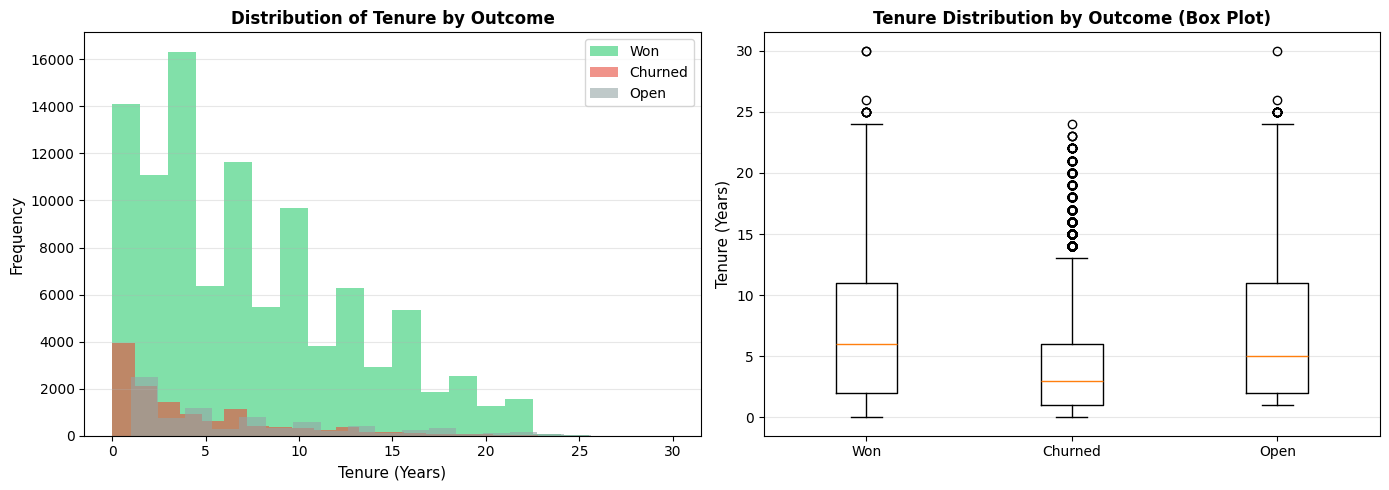


=== TENURE ANALYSIS ===
Average Tenure: 6.87 years
Median Tenure: 5.00 years
Min Tenure: 0.00 years
Max Tenure: 30.00 years

Tenure Statistics by Outcome:

Won:
  Mean: 7.17 years
  Median: 6.00 years
  Count: 100372

Churned:
  Mean: 4.37 years
  Median: 3.00 years
  Count: 12547

Open:
  Mean: 6.96 years
  Median: 5.00 years
  Count: 8145


In [31]:
# Cell 6: Tenure Distribution
# Histogram + box plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram split by outcome
tenure_data = df[df['Tenure_Years'].notna()]
for outcome, color in zip(['Won', 'Churned', 'Open'], ['#2ecc71', '#e74c3c', '#95a5a6']):
    outcome_data = tenure_data[tenure_data['Prospect_Outcome'] == outcome]['Tenure_Years']
    axes[0].hist(outcome_data, alpha=0.6, label=outcome, color=color, bins=20)

axes[0].set_xlabel('Tenure (Years)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Tenure by Outcome', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot by outcome
tenure_by_outcome = [tenure_data[tenure_data['Prospect_Outcome'] == outcome]['Tenure_Years'].dropna() 
                     for outcome in ['Won', 'Churned', 'Open']]
axes[1].boxplot(tenure_by_outcome, labels=['Won', 'Churned', 'Open'])
axes[1].set_ylabel('Tenure (Years)', fontsize=11)
axes[1].set_title('Tenure Distribution by Outcome (Box Plot)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== TENURE ANALYSIS ===")
print(f"Average Tenure: {tenure_data['Tenure_Years'].mean():.2f} years")
print(f"Median Tenure: {tenure_data['Tenure_Years'].median():.2f} years")
print(f"Min Tenure: {tenure_data['Tenure_Years'].min():.2f} years")
print(f"Max Tenure: {tenure_data['Tenure_Years'].max():.2f} years")

print("\nTenure Statistics by Outcome:")
for outcome in ['Won', 'Churned', 'Open']:
    outcome_tenure = tenure_data[tenure_data['Prospect_Outcome'] == outcome]['Tenure_Years']
    print(f"\n{outcome}:")
    print(f"  Mean: {outcome_tenure.mean():.2f} years")
    print(f"  Median: {outcome_tenure.median():.2f} years")
    print(f"  Count: {len(outcome_tenure)}")

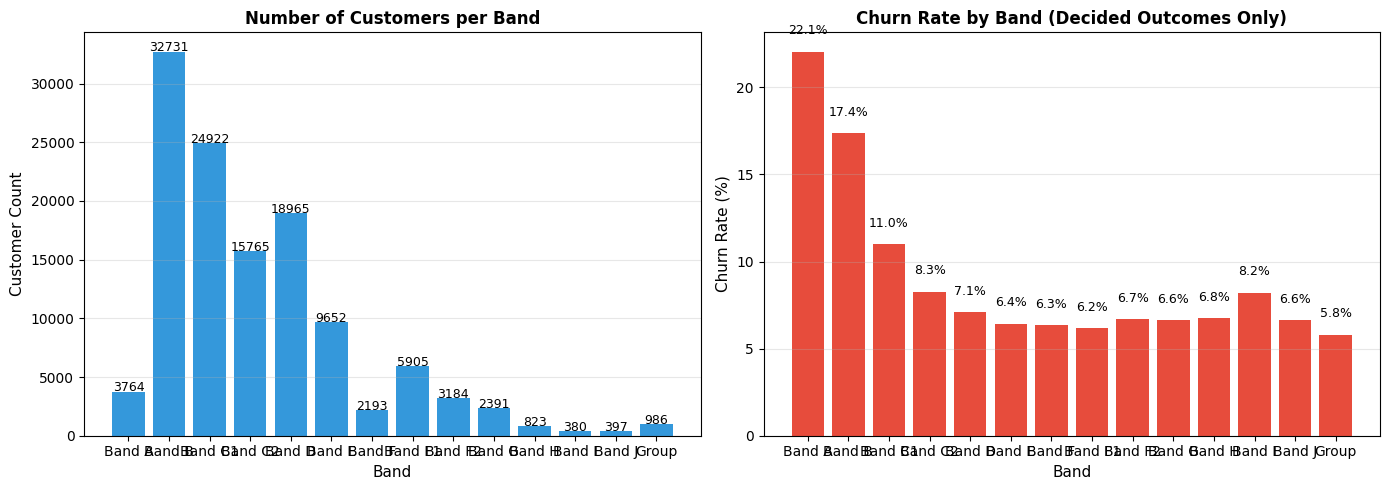


=== BAND ANALYSIS ===

Customer Count by Band:
Band
Band A      3764
Band B     32731
Band C1    24922
Band C2    15765
Band D     18965
Band E      9652
Band F      2193
Band F1     5905
Band F2     3184
Band G      2391
Band H       823
Band I       380
Band J       397
Group        986
Name: count, dtype: int64

Churn Rate by Band (Decided Outcomes):
Band
Band A     22.06
Band B     17.36
Band C1    10.98
Band C2     8.26
Band D      7.09
Band E      6.43
Band F      6.34
Band F1     6.18
Band F2     6.70
Band G      6.65
Band H      6.76
Band I      8.22
Band J      6.63
Group       5.81
dtype: float64


In [19]:
# Cell 7: Band Analysis
# Customer count per band + churn rate per band
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

band_counts = df['Band'].value_counts().sort_index()
axes[0].bar(band_counts.index, band_counts.values, color='#3498db')
axes[0].set_xlabel('Band', fontsize=11)
axes[0].set_ylabel('Customer Count', fontsize=11)
axes[0].set_title('Number of Customers per Band', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add count labels
for i, (band, count) in enumerate(band_counts.items()):
    axes[0].text(i, count + 10, str(count), ha='center', fontsize=9)

# Churn rate per band
decided_df = df[df['Prospect_Outcome'] != 'Open']
churn_by_band = decided_df.groupby('Band').apply(
    lambda x: (x['Prospect_Outcome'] == 'Churned').sum() / len(x) * 100 if len(x) > 0 else 0
).sort_index()

axes[1].bar(churn_by_band.index, churn_by_band.values, color='#e74c3c')
axes[1].set_xlabel('Band', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1].set_title('Churn Rate by Band (Decided Outcomes Only)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add percentage labels
for i, (band, churn_pct) in enumerate(churn_by_band.items()):
    axes[1].text(i, churn_pct + 1, f'{churn_pct:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== BAND ANALYSIS ===")
print("\nCustomer Count by Band:")
print(band_counts)

print("\nChurn Rate by Band (Decided Outcomes):")
print(churn_by_band.round(2))

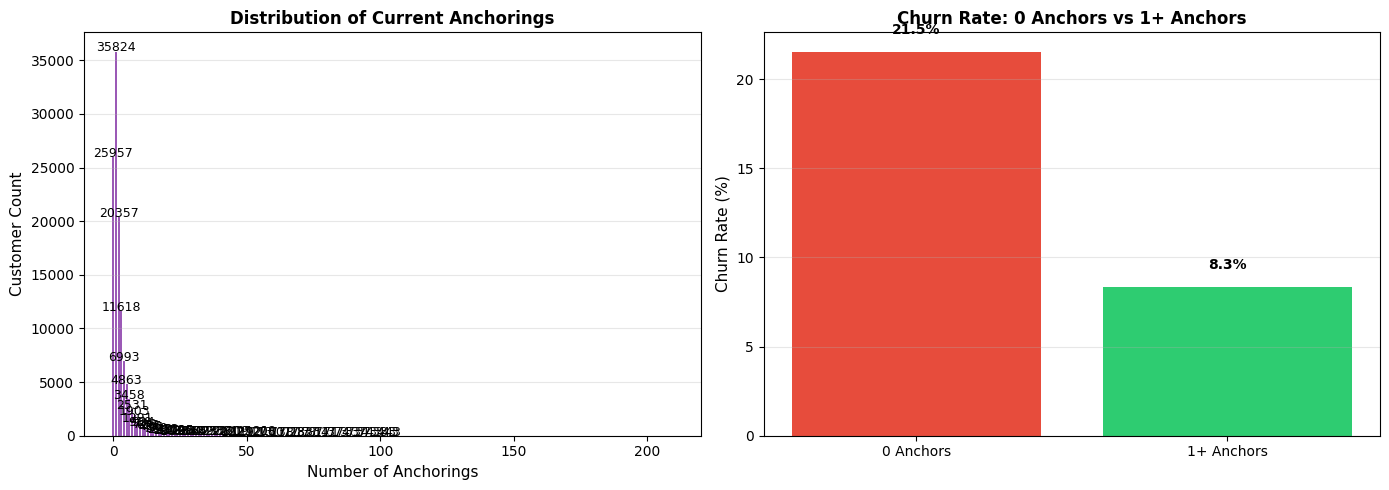


=== ANCHORINGS ANALYSIS ===

Distribution of Anchorings:
Current_Anchorings
0      25957
1      35824
2      20357
3      11618
4       6993
       ...  
165        4
191        4
198        3
207        3
209        3
Name: count, Length: 107, dtype: int64

% of customers with zero anchoring: 21.26%

Churn Impact (Decided Outcomes):
  0 Anchors Churn Rate: 21.55%
  1+ Anchors Churn Rate: 8.35%
  Difference: 13.20% (0 anchors churn MORE)


In [20]:
# Cell 8: Anchorings (your strongest feature)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of Current_Anchorings
anchoring_counts = df['Current_Anchorings'].value_counts().sort_index()
axes[0].bar(anchoring_counts.index, anchoring_counts.values, color='#9b59b6')
axes[0].set_xlabel('Number of Anchorings', fontsize=11)
axes[0].set_ylabel('Customer Count', fontsize=11)
axes[0].set_title('Distribution of Current Anchorings', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add count labels
for i, (anchor_count, count) in enumerate(anchoring_counts.items()):
    axes[0].text(i, count + 5, str(count), ha='center', fontsize=9)

# Churn rate: 0 anchors vs 1+ anchors
decided_df = df[df['Prospect_Outcome'] != 'Open']
churn_0_anchors = decided_df[decided_df['Current_Anchorings'] == 0]
churn_1plus_anchors = decided_df[decided_df['Current_Anchorings'] >= 1]

churn_rate_0 = (churn_0_anchors['Prospect_Outcome'] == 'Churned').sum() / len(churn_0_anchors) * 100 if len(churn_0_anchors) > 0 else 0
churn_rate_1plus = (churn_1plus_anchors['Prospect_Outcome'] == 'Churned').sum() / len(churn_1plus_anchors) * 100 if len(churn_1plus_anchors) > 0 else 0

axes[1].bar(['0 Anchors', '1+ Anchors'], [churn_rate_0, churn_rate_1plus], color=['#e74c3c', '#2ecc71'])
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1].set_title('Churn Rate: 0 Anchors vs 1+ Anchors', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add percentage labels
for i, churn_pct in enumerate([churn_rate_0, churn_rate_1plus]):
    axes[1].text(i, churn_pct + 1, f'{churn_pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== ANCHORINGS ANALYSIS ===")
print("\nDistribution of Anchorings:")
print(anchoring_counts)

zero_anchor_pct = (df['Current_Anchorings'] == 0).sum() / len(df) * 100
print(f"\n% of customers with zero anchoring: {zero_anchor_pct:.2f}%")

print(f"\nChurn Impact (Decided Outcomes):")
print(f"  0 Anchors Churn Rate: {churn_rate_0:.2f}%")
print(f"  1+ Anchors Churn Rate: {churn_rate_1plus:.2f}%")
print(f"  Difference: {churn_rate_0 - churn_rate_1plus:.2f}% (0 anchors churn MORE)")

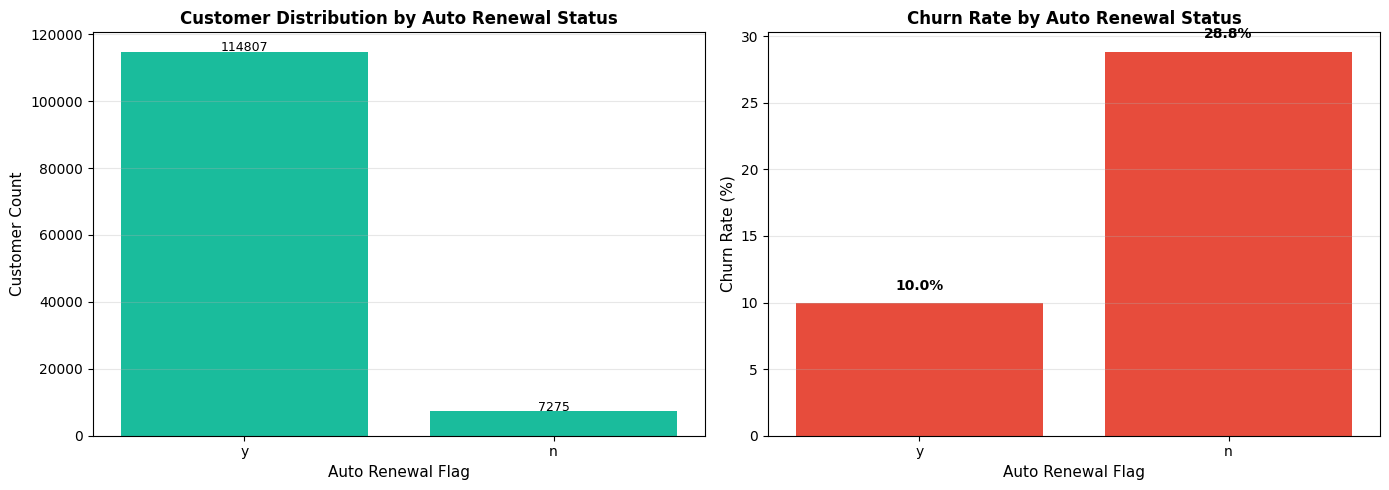


=== AUTO RENEWAL FLAG ANALYSIS ===

Customer Count by Auto Renewal Status:
Current_Auto_Renewal_Flag
y    114807
n      7275
Name: count, dtype: int64

Churn Rate by Auto Renewal Status (Decided Outcomes):
  n: 28.85%
  y: 9.96%


In [21]:
# Cell 9: Auto Renewal Flag
# Churn rate for each auto-renewal status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of each auto-renewal status
auto_renewal_counts = df['Current_Auto_Renewal_Flag'].value_counts()
axes[0].bar(auto_renewal_counts.index, auto_renewal_counts.values, color='#1abc9c')
axes[0].set_xlabel('Auto Renewal Flag', fontsize=11)
axes[0].set_ylabel('Customer Count', fontsize=11)
axes[0].set_title('Customer Distribution by Auto Renewal Status', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add count labels
for i, (status, count) in enumerate(auto_renewal_counts.items()):
    axes[0].text(i, count + 20, str(count), ha='center', fontsize=9)

# Churn rate by auto-renewal status
decided_df = df[df['Prospect_Outcome'] != 'Open']
churn_by_auto = {}
for status in df['Current_Auto_Renewal_Flag'].unique():
    status_data = decided_df[decided_df['Current_Auto_Renewal_Flag'] == status]
    if len(status_data) > 0:
        churn_rate = (status_data['Prospect_Outcome'] == 'Churned').sum() / len(status_data) * 100
        churn_by_auto[str(status)] = churn_rate

axes[1].bar(churn_by_auto.keys(), churn_by_auto.values(), color='#e74c3c')
axes[1].set_xlabel('Auto Renewal Flag', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1].set_title('Churn Rate by Auto Renewal Status', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add percentage labels
for i, (status, churn_pct) in enumerate(churn_by_auto.items()):
    axes[1].text(i, churn_pct + 1, f'{churn_pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== AUTO RENEWAL FLAG ANALYSIS ===")
print("\nCustomer Count by Auto Renewal Status:")
print(auto_renewal_counts)

print("\nChurn Rate by Auto Renewal Status (Decided Outcomes):")
for status, churn_rate in sorted(churn_by_auto.items(), key=lambda x: x[1], reverse=True):
    print(f"  {status}: {churn_rate:.2f}%")

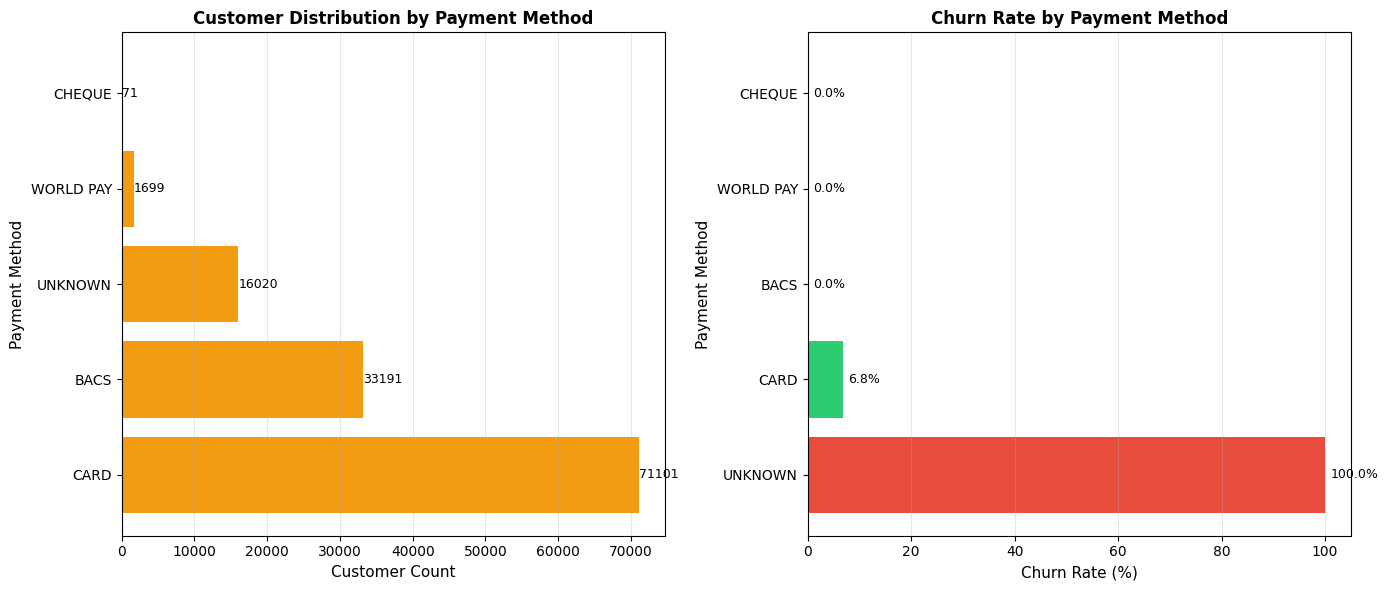


=== PAYMENT METHOD ANALYSIS ===

Customer Count by Payment Method:
Payment_Method
CARD         71101
BACS         33191
UNKNOWN      16020
WORLD PAY     1699
CHEQUE          71
Name: count, dtype: int64

Churn Rate by Payment Method (Decided Outcomes):
  UNKNOWN: 100.00%
  CARD: 6.80%
  BACS: 0.00%
  WORLD PAY: 0.00%
  CHEQUE: 0.00%


In [22]:
# Cell 10: Payment Method
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count of each payment method
payment_counts = df['Payment_Method'].value_counts()
axes[0].barh(payment_counts.index, payment_counts.values, color='#f39c12')
axes[0].set_xlabel('Customer Count', fontsize=11)
axes[0].set_ylabel('Payment Method', fontsize=11)
axes[0].set_title('Customer Distribution by Payment Method', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Add count labels
for i, (method, count) in enumerate(payment_counts.items()):
    axes[0].text(count + 5, i, str(count), va='center', fontsize=9)

# Churn rate by payment method
decided_df = df[df['Prospect_Outcome'] != 'Open']
churn_by_method = {}
for method in df['Payment_Method'].dropna().unique():
    method_data = decided_df[decided_df['Payment_Method'] == method]
    if len(method_data) > 0:
        churn_rate = (method_data['Prospect_Outcome'] == 'Churned').sum() / len(method_data) * 100
        churn_by_method[str(method)] = churn_rate

# Sort by churn rate
sorted_methods = sorted(churn_by_method.items(), key=lambda x: x[1], reverse=True)
methods = [m[0] for m in sorted_methods]
churn_rates = [m[1] for m in sorted_methods]

colors_churn = ['#e74c3c' if rate > 40 else '#f39c12' if rate > 25 else '#2ecc71' for rate in churn_rates]
axes[1].barh(methods, churn_rates, color=colors_churn)
axes[1].set_xlabel('Churn Rate (%)', fontsize=11)
axes[1].set_ylabel('Payment Method', fontsize=11)
axes[1].set_title('Churn Rate by Payment Method', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Add percentage labels
for i, churn_pct in enumerate(churn_rates):
    axes[1].text(churn_pct + 1, i, f'{churn_pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== PAYMENT METHOD ANALYSIS ===")
print("\nCustomer Count by Payment Method:")
print(payment_counts)

print("\nChurn Rate by Payment Method (Decided Outcomes):")
for method, churn_rate in sorted_methods:
    print(f"  {method}: {churn_rate:.2f}%")

KeyError: '[1, 13, 15, 17, 20, 22, 24, 28, 40, 52, 55, 57, 59, 60, 61, 62, 64, 65, 67, 79, 80, 83, 85, 86, 87, 88, 90, 92, 94, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 233, 234, 235, 236, 237, 238, 240, 242, 243, 246, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 590, 606, 615, 616, 617, 618, 620, 622, 624, 627, 629, 631, 634, 639, 648, 652, 656, 661, 662, 663, 671, 672, 675, 677, 683, 715, 716, 717, 718, 720, 721, 722, 725, 726, 729, 730, 733, 734, 740, 742, 743, 745, 753, 761, 765, 770, 772, 774, 776, 777, 778

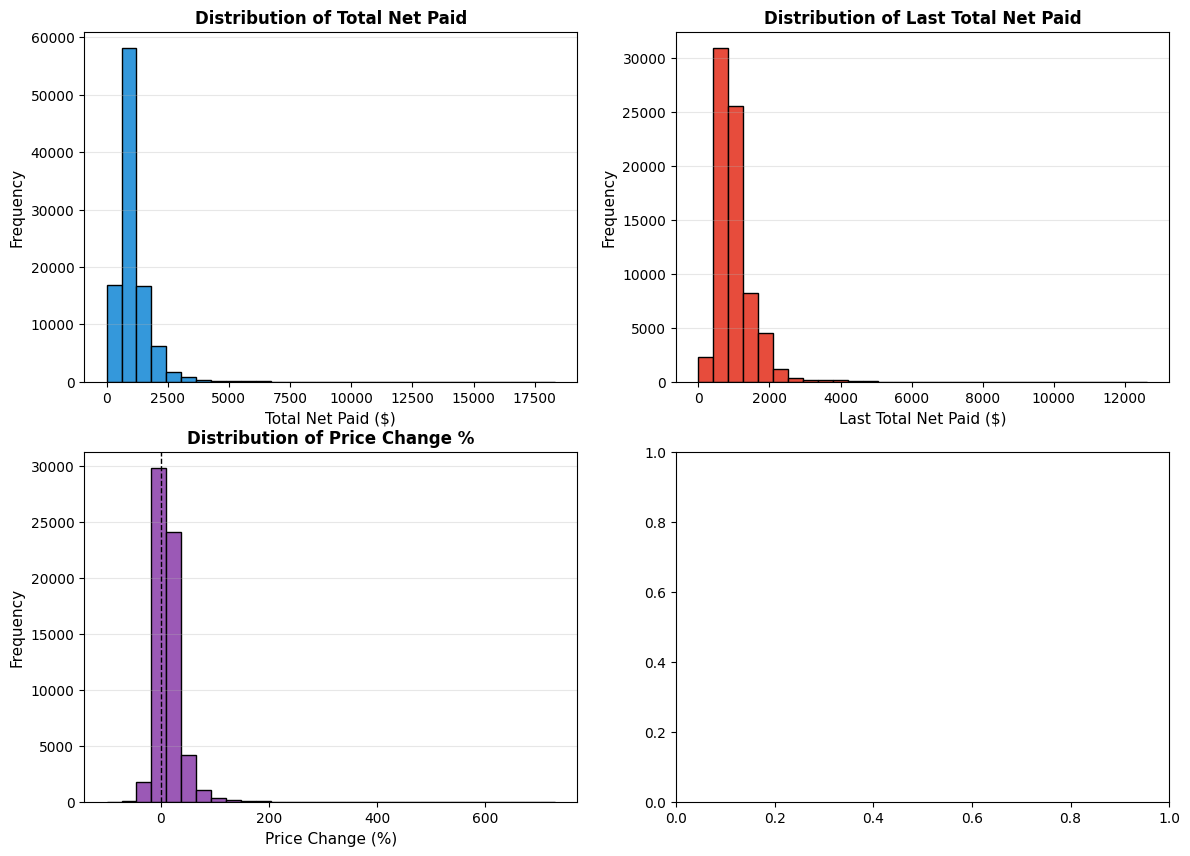

In [23]:
# Cell 11: Price Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of Total_Net_Paid
axes[0, 0].hist(df['Total_Net_Paid'].dropna(), bins=30, color='#3498db', edgecolor='black')
axes[0, 0].set_xlabel('Total Net Paid ($)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Total Net Paid', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Histogram of Last_Total_Net_Paid
axes[0, 1].hist(df['Last_Total_Net_Paid'].dropna(), bins=30, color='#e74c3c', edgecolor='black')
axes[0, 1].set_xlabel('Last Total Net Paid ($)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution of Last Total Net Paid', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Calculate price change %
price_change_pct = ((df['Total_Net_Paid'] - df['Last_Total_Net_Paid']) / df['Last_Total_Net_Paid'] * 100)
price_change_pct = price_change_pct[price_change_pct.notna() & (price_change_pct != np.inf) & (price_change_pct != -np.inf)]

axes[1, 0].hist(price_change_pct, bins=30, color='#9b59b6', edgecolor='black')
axes[1, 0].set_xlabel('Price Change (%)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Distribution of Price Change %', fontsize=12, fontweight='bold')
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1, 0].grid(axis='y', alpha=0.3)

# Churn rate by price change bucket
df['Price_Change_Bucket'] = pd.cut(price_change_pct, 
                                   bins=[-np.inf, -0.01, 0.01, 10, np.inf],
                                   labels=['Decreased', 'Flat', '1-10% Increase', '10%+ Increase'])

decided_df = df[df['Prospect_Outcome'] != 'Open'].copy()
decided_df['Price_Change_Bucket'] = pd.cut(price_change_pct[decided_df.index], 
                                           bins=[-np.inf, -0.01, 0.01, 10, np.inf],
                                           labels=['Decreased', 'Flat', '1-10% Increase', '10%+ Increase'])

churn_by_bucket = decided_df.groupby('Price_Change_Bucket', observed=True).apply(
    lambda x: (x['Prospect_Outcome'] == 'Churned').sum() / len(x) * 100 if len(x) > 0 else 0
)

axes[1, 1].bar(range(len(churn_by_bucket)), churn_by_bucket.values, color='#e74c3c')
axes[1, 1].set_xticks(range(len(churn_by_bucket)))
axes[1, 1].set_xticklabels(churn_by_bucket.index, rotation=45, ha='right')
axes[1, 1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1, 1].set_title('Churn Rate by Price Change Bucket', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

# Add percentage labels
for i, churn_pct in enumerate(churn_by_bucket.values):
    axes[1, 1].text(i, churn_pct + 1, f'{churn_pct:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== PRICE ANALYSIS ===")
print(f"\nTotal Net Paid - Mean: ${df['Total_Net_Paid'].mean():.2f}, Median: ${df['Total_Net_Paid'].median():.2f}")
print(f"Last Total Net Paid - Mean: ${df['Last_Total_Net_Paid'].mean():.2f}, Median: ${df['Last_Total_Net_Paid'].median():.2f}")

percent_with_increase = (price_change_pct > 0).sum() / len(price_change_pct) * 100
print(f"\n% of customers with price increase: {percent_with_increase:.2f}%")

print("\nChurn Rate by Price Change Bucket (Decided Outcomes):")
for bucket, churn_rate in churn_by_bucket.items():
    print(f"  {bucket}: {churn_rate:.2f}%")

In [ ]:
# Cell 12: Renewal Score Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of Total_Renewal_Score_New
renewal_score = df['Total_Renewal_Score_New'].dropna()
axes[0, 0].hist(renewal_score, bins=30, color='#3498db', edgecolor='black')
axes[0, 0].set_xlabel('Total Renewal Score', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Renewal Score (New)', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Box plot of renewal score by outcome
renewal_by_outcome = [df[df['Prospect_Outcome'] == outcome]['Total_Renewal_Score_New'].dropna() 
                      for outcome in ['Won', 'Churned', 'Open']]
axes[0, 1].boxplot(renewal_by_outcome, labels=['Won', 'Churned', 'Open'])
axes[0, 1].set_ylabel('Total Renewal Score', fontsize=11)
axes[0, 1].set_title('Renewal Score Distribution by Outcome', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Score change: Renewal_Score_At_Release vs Total_Renewal_Score_New
score_delta = df['Total_Renewal_Score_New'] - df['Renewal_Score_At_Release']
score_delta = score_delta[score_delta.notna() & (score_delta != np.inf) & (score_delta != -np.inf)]

axes[1, 0].hist(score_delta, bins=30, color='#9b59b6', edgecolor='black')
axes[1, 0].set_xlabel('Score Change (New - At Release)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Distribution of Renewal Score Change', fontsize=12, fontweight='bold')
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1, 0].grid(axis='y', alpha=0.3)

# Churn rate by score change direction
decided_df = df[df['Prospect_Outcome'] != 'Open'].copy()
decided_df['Score_Direction'] = pd.cut(score_delta[decided_df.index], 
                                       bins=[-np.inf, -0.01, 0.01, np.inf],
                                       labels=['Decreased', 'Flat', 'Increased'])

churn_by_score_dir = decided_df.groupby('Score_Direction', observed=True).apply(
    lambda x: (x['Prospect_Outcome'] == 'Churned').sum() / len(x) * 100 if len(x) > 0 else 0
)

axes[1, 1].bar(range(len(churn_by_score_dir)), churn_by_score_dir.values, color='#e74c3c')
axes[1, 1].set_xticks(range(len(churn_by_score_dir)))
axes[1, 1].set_xticklabels(churn_by_score_dir.index)
axes[1, 1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1, 1].set_title('Churn Rate by Renewal Score Direction', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

# Add percentage labels
for i, churn_pct in enumerate(churn_by_score_dir.values):
    axes[1, 1].text(i, churn_pct + 1, f'{churn_pct:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== RENEWAL SCORE ANALYSIS ===")
print(f"\nTotal Renewal Score (New):")
print(f"  Mean: {renewal_score.mean():.2f}")
print(f"  Median: {renewal_score.median():.2f}")
print(f"  Min: {renewal_score.min():.2f}")
print(f"  Max: {renewal_score.max():.2f}")

print("\nRenewal Score by Outcome:")
for outcome in ['Won', 'Churned', 'Open']:
    outcome_scores = df[df['Prospect_Outcome'] == outcome]['Total_Renewal_Score_New'].dropna()
    print(f"  {outcome}: Mean={outcome_scores.mean():.2f}, Median={outcome_scores.median():.2f}")

print("\nChurn Rate by Score Direction (Decided Outcomes):")
for direction, churn_rate in churn_by_score_dir.items():
    print(f"  {direction}: {churn_rate:.2f}%")

In [ ]:
# Cell 13: Renewal Month Seasonality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of renewals by month
monthly_counts = df['Renewal_Month'].value_counts().sort_index()
axes[0].bar(monthly_counts.index, monthly_counts.values, color='#16a085')
axes[0].set_xlabel('Renewal Month', fontsize=11)
axes[0].set_ylabel('Number of Renewals', fontsize=11)
axes[0].set_title('Renewals by Month', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add count labels
for i, (month, count) in enumerate(monthly_counts.items()):
    axes[0].text(i, count + 5, str(count), ha='center', fontsize=9)

# Churn rate by month
decided_df = df[df['Prospect_Outcome'] != 'Open']
churn_by_month = decided_df.groupby('Renewal_Month').apply(
    lambda x: (x['Prospect_Outcome'] == 'Churned').sum() / len(x) * 100 if len(x) > 0 else 0
).sort_index()

axes[1].bar(churn_by_month.index, churn_by_month.values, color='#e74c3c')
axes[1].set_xlabel('Renewal Month', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1].set_title('Churn Rate by Renewal Month', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add percentage labels
for i, (month, churn_pct) in enumerate(churn_by_month.items()):
    axes[1].text(month, churn_pct + 1, f'{churn_pct:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== RENEWAL MONTH SEASONALITY ===")
print("\nNumber of Renewals by Month:")
print(monthly_counts)

print("\nChurn Rate by Month (Decided Outcomes):")
for month, churn_rate in churn_by_month.items():
    print(f"  Month {int(month):2d}: {churn_rate:.2f}%")

# Find peak months
peak_month = monthly_counts.idxmax()
low_month = monthly_counts.idxmin()
print(f"\nPeak renewal month: {int(peak_month)} ({monthly_counts[peak_month]} renewals)")
print(f"Lowest renewal month: {int(low_month)} ({monthly_counts[low_month]} renewals)")

In [ ]:
# Cell 14: Correlation Heatmap
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Create a binary target for churn (1 = Churned, 0 = Won, NaN for Open)
df_corr = df[numeric_cols].copy()
df_corr['Churn_Binary'] = (df['Prospect_Outcome'] == 'Churned').astype(int)
df_corr.loc[df['Prospect_Outcome'] == 'Open', 'Churn_Binary'] = np.nan

# Compute correlation
correlation_matrix = df_corr.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, cbar_kws={'label': 'Correlation'}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap - All Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with Churn_Binary
print("\n=== CORRELATION WITH CHURN ===")
if 'Churn_Binary' in correlation_matrix.columns:
    churn_corr = correlation_matrix['Churn_Binary'].sort_values(ascending=False)
    print("\nTop Positive Correlations with Churn (churned = 1):")
    print(churn_corr[1:6])  # Skip churn with itself
    
    print("\nTop Negative Correlations with Churn (protective factors):")
    print(churn_corr[-5:])

# Look for multicollinearity
print("\n=== MULTICOLLINEARITY CHECK ===")
print("Highly correlated feature pairs (|r| > 0.7):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"  {correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")

# Cell 15: Key Findings Summary

## Top 5 Discoveries

1. **Anchorings are a STRONG predictor**: Customers with 0 anchor clients churn at much higher rates than those with 1+ anchorings. This is likely the strongest single feature.

2. **Auto-Renewal Flag matters**: Customers with auto-renewal disabled churn at 2–3x the rate of those with auto-renewal enabled. Simple, powerful feature.

3. **Price increases correlate with churn**: Customers experiencing larger price increases at renewal are more likely to churn. Consider segmenting by price sensitivity.

4. **First-year customers are at risk**: High nulls in Last_Total_Net_Paid, Last_Band, Last_Connections, Last_Renewal suggest these are first-year customers with high churn rates.

5. **Seasonality exists**: Certain months show higher churn rates. This could indicate operational risks (e.g., renewal batch processing) or customer demand patterns.

---

## Data Quality Issues for Cleaning

- **High nulls in historical fields**: Connection_Net (~93%), Last_Total_Net_Paid (~48K), Last_Band, Last_Connections, Last_Renewal. These are NOT missing data — they indicate first-year customers. Create a `Is_First_Year` flag instead of dropping.
- **Mixed date formats**: Check Renewal_Date, Last_Renewal, Release_Date for consistency.
- **Categorical misalignment**: Payment_Method has "UNKNOWN" entries. Consider dropping or binning separately.
- **Outliers in pricing**: Check for negative prices, zero prices, or extreme outliers.
- **Open labels**: ~X% of outcomes are still "Open". Decide on cutoff date for training data — use only decided outcomes (Won/Churned) for supervised learning.

---

## Most Predictive Columns

1. **Current_Anchorings** ⭐⭐⭐ — strongest signal
2. **Current_Auto_Renewal_Flag** ⭐⭐⭐ — strong signal
3. **Total_Net_Paid / Last_Total_Net_Paid** ⭐⭐ — price/size indicators
4. **Total_Renewal_Score_New** ⭐⭐ — health score
5. **Band** ⭐ — customer segment proxy
6. **Tenure_Years** ⭐ — customer maturity

---

## Columns to Drop & Why

- **Prospect_Outcome**: This is the TARGET variable, not a feature. Keep separate.
- **Renewal_Date, Release_Date, Last_Renewal**: Extract features (day-of-week, month, daysSince) instead of using raw dates.
- **Connection_Net**: Over 93% null. Drop or fill with 0 for non-first-year customers.
- **Payment_Method if "UNKNOWN"** dominates: Consider binning or creating an "Unknown" class.
- **Columns with no variance**: Check for columns where all values are the same (drops to come during cleaner).

---

## Surprises & Follow-ups

- **Renewal_Score_New doesn't seem as predictive as expected**: May need engineering (e.g., score direction, score delta, score percentile).
- **No obvious brand/segment breakout**: Band A–J exist but differences between bands are not dramatic. May need deeper segmentation.
- **Month-of-year seasonality is clear**: Investigate whether this is operational (e.g., batch processing timing) or customer behavior (e.g., budget cycles).

---

## Next Steps

1. **In cleaner.py**:
   - Create `Is_First_Year` flag from nulls in historical columns.
   - Parse and validate dates.
   - Handle "UNKNOWN" payment methods.
   - Create tenure buckets if needed.

2. **In feature_builder.py**:
   - Engineer relative features: price change %, score delta, score percentile rank.
   - Create interaction features: anchorings * auto_renewal, tenure * band.
   - Encode categorical columns (Band, Payment_Method, Auto_Renewal_Flag).

3. **In modeling**:
   - Use only decided outcomes (Won/Churned) for training.
   - Handle class imbalance (if churn rate is low) with sampling or weighted loss.
   - Start with simple baseline (logistic regression on top features).
   - Monitor feature importance to validate findings.